<a href="https://colab.research.google.com/github/RaniaChaudhry511/SUPERWISED-MACHINE-LEARING-MODEL/blob/main/linear_regression_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                      LINEAR REGRESSION(ALOGORITHM) PROJECT

                                                  HOUSE PRICE PREDICTION USING LINEAR REGRESSION

                                                              PART 1 DATA LOADING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("/content/House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


                                                            PART 2 DATA CLEANNG

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

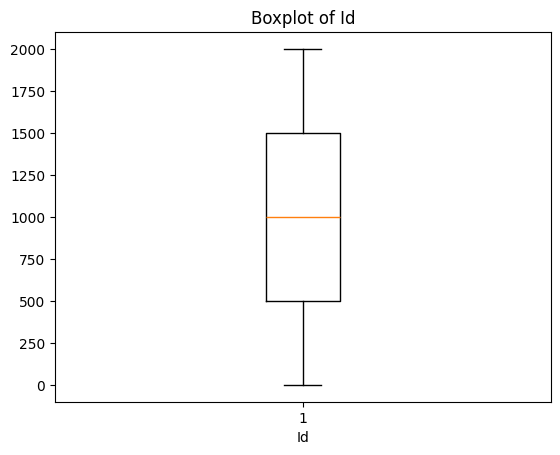

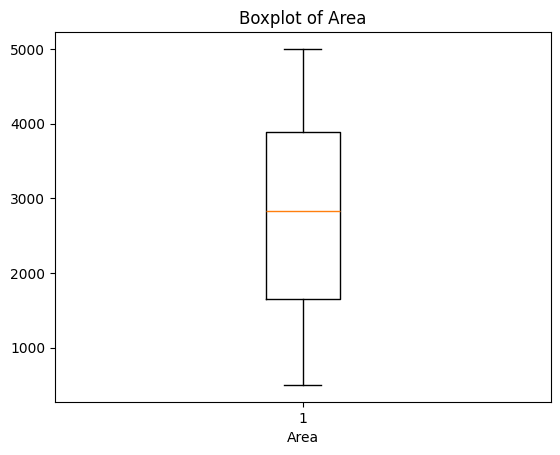

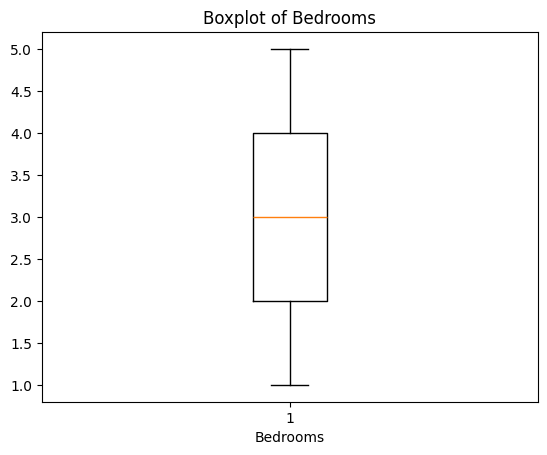

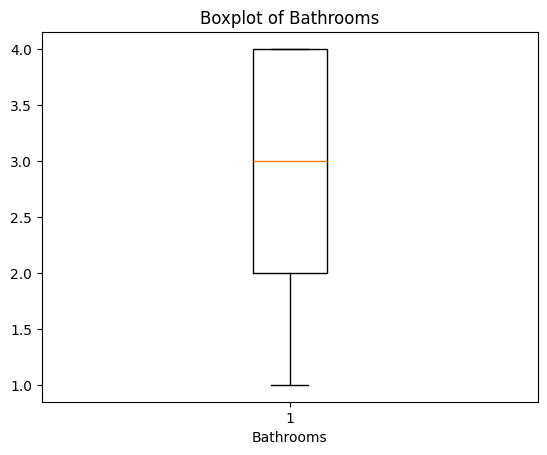

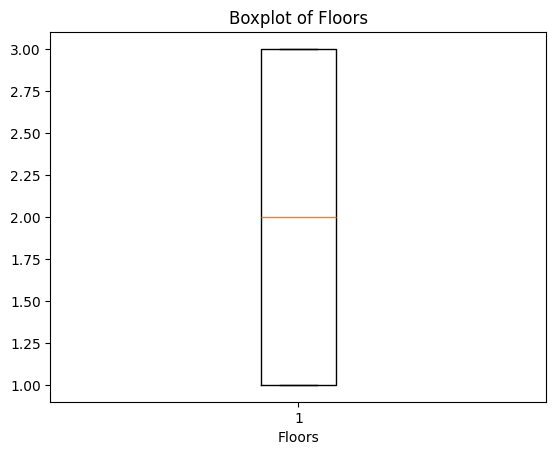

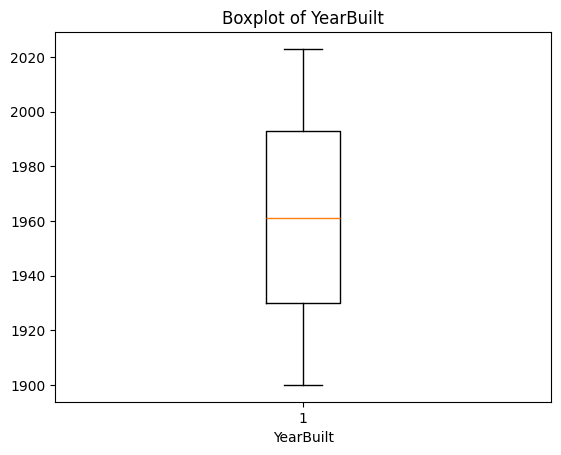

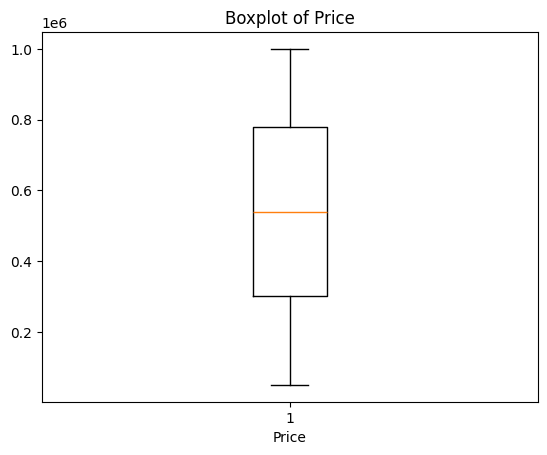

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

print(df.head())
print(df.dtypes)

   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Condition  Garage   Price  \
0  1360         5          4       3       1970          0       0  149919   
1  4272         5          4       3       1958          0       0  424998   
2  3592         2          2       3       1938          2       0  266746   
3   966         4          2       2       1902          1       1  244020   
4  4926         1          4       2       1975          1       1  636056   

   Location_Downtown  Location_Rural  Location_Suburban  Location_Urban  
0                  1               0                  0               0  
1                  1               0                  0               0  
2                  1               0                  0               0  
3                  0               0                  1               0  
4                  1               0                  0               0  
Area                 int64
Bedrooms             int64
Bathrooms            int64
Floors

droping id column

In [ ]:
df.drop('Id', axis=1, inplace=True)
print(df.shape)

(2000, 12)


                                                          FEATURE ENGINNERING

In [ ]:
df['House_Age'] = 2024 - df['YearBuilt']
df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']
df['Price_per_sqft'] = df['Price'] / df['Area']

print(df[['House_Age', 'Total_Rooms', 'Price_per_sqft']].head())

   House_Age  Total_Rooms  Price_per_sqft
0         54            9      110.234559
1         66            9       99.484551
2         86            4       74.261136
3        122            6      252.608696
4         49            5      129.122209


                                                               TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

# Features aur target alag karo
X = df.drop('Price', axis=1)
y = df['Price']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1600, 14)
X_test: (400, 14)
y_train: (1600,)
y_test: (400,)


                                                     MODEL SELECTION AND TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression

# Model select karo
model = LinearRegression()

# Model train karo
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


                                                            MODEL PREDICTION

In [ ]:
# Prediction karo
y_pred = model.predict(X_test)

print("Predicted values (first 5):", y_pred[:5])
print("Actual values (first 5):", y_test.values[:5])

Predicted values (first 5): [716693.17739011 553790.39357116 194642.02571474 518687.03807917
 384015.51383249]
Actual values (first 5): [514764 694256  66375 650243 223285]


                                                                  MODEL EVALUATION

In [ ]:
from sklearn.metrics import mean_absolute_error

df.drop('Price_per_sqft', axis=1, inplace=True)

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: -0.005900816157381028
MAE: 243304.23188184068


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Fresh load
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

# Cleaning
le = LabelEncoder()
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])
df = pd.get_dummies(df, columns=['Location'], drop_first=False)
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
df.drop('Id', axis=1, inplace=True)

# Feature Engineering
df['House_Age'] = 2024 - df['YearBuilt']
df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']

# Split
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.005900816157381028
MAE: 243304.23188184068


In [ ]:
print(df.columns.tolist())

['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition', 'Garage', 'Price', 'Location_Downtown', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'House_Age', 'Total_Rooms']


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.005900816157381028
MAE: 243304.23188184068


CONCLUSION:

This project implements a Linear Regression algorithm
to predict house prices.

- Dataset: House Price Prediction Dataset
- Total Records: 2000
- Algorithm: Linear Regression
- R2 Score: -0.005
- MAE: 243,304

The model did not perform well on this dataset.
The reason is that the dataset had quality issues
and was not suitable for accurate house price
prediction.

This proves that model performance depends on
the quality of the dataset. A better dataset
will give better results.